# Introduction

We will be using the [NHANES 2003-2004](https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=2003) data set. We will see how the height of men between the ages of 18&ndash;24 is correlated to their weight.

From the [Demographics data](https://wwwn.cdc.gov/nchs/nhanes/search/datapage.aspx?Component=Demographics&CycleBeginYear=2003)
we are specifically interested in [RIAGENDR](https://wwwn.cdc.gov/Nchs/Nhanes/2003-2004/DEMO_C.htm#RIAGENDR) variable and the
[RIDAGEEX](https://wwwn.cdc.gov/Nchs/Nhanes/2003-2004/DEMO_C.htm#RIDAGEEX) variable,
to filter out men between ages 18 (216 months) and 24 (288 months).

We will be using the `haven`.

In [1]:
require(haven)
#demo <- read_xpt(url('https://wwwn.cdc.gov/Nchs/Nhanes/2003-2004/DEMO_C.XPT'))
demo <- read_xpt('../../09 Data Sets/DEMO_C.XPT')
males <- demo[demo$RIAGENDR == 1 & demo$RIDAGEEX >= 216 & demo$RIDAGEEX <= 288,]$SEQN

Loading required package: haven



We now have the `SEQN` number for all participants in the study that are men ages 18&ndash;24. We can now retrieve the data for these
individuals using this `SEQN` number. The variables we are interested in are
[BMXHT](https://wwwn.cdc.gov/Nchs/Nhanes/2003-2004/BMX_C.htm#BMXHT) and 
[BMXWT](https://wwwn.cdc.gov/Nchs/Nhanes/2003-2004/BMX_C.htm#BMXWT). They are in centimeters and kilograms respectively but we want them in inches and pounds.

In [5]:
#bm <- read_xpt(url('https://wwwn.cdc.gov/Nchs/Nhanes/2003-2004/BMX_C.XPT'))
bmx <- read_xpt('../../09 Data Sets/BMX_C.XPT')
x <- as.data.frame(na.omit(bmx[bmx$SEQN %in% males,c('BMXHT','BMXWT')]))
# Convert to inches and pounds
df <- data.frame(
    height = x$BMXHT * .4,
    weight = x$BMXWT * 2.2
)

We round the summary statistics for simplicity:

In [7]:
old.digits = getOption("digits")
options(digits=1)
cat("Summary Statistics:\n\t", 
    "average height:", (m.ht <- mean(df$height)), "inches,  SD:", (sd.ht <- sd(df$height)), "inches\n\t",
    "average weight:", (m.wt <- mean(df$weight)), "pounds,  SD:", (sd.wt <- sd(df$weight)), "pounds\n\t\n\t",
    "correlation (r):", (cor.men <- cor(df$height, df$weight)))
options(digits=old.digits)

Summary Statistics:
	 average height: 71 inches,  SD: 3 inches
	 average weight: 176 pounds,  SD: 47 pounds
	
	 correlation (r): 0.4

The following is the scatter plot for the data set. The vertical stip represents men who are about one SD above average in height. Those who are also one SD above average weight would be plotted along the dashed SD line. Most of the men in the strip are below the SD line: they are only part of an SD above average in weight. The solid regression line estimates average weight at each height. The `xlim` and `ylim` have been choosen so that one SD of height and one SD of weight cover the same distance. This makes the SD line (dashed) rise at 45 degrees.

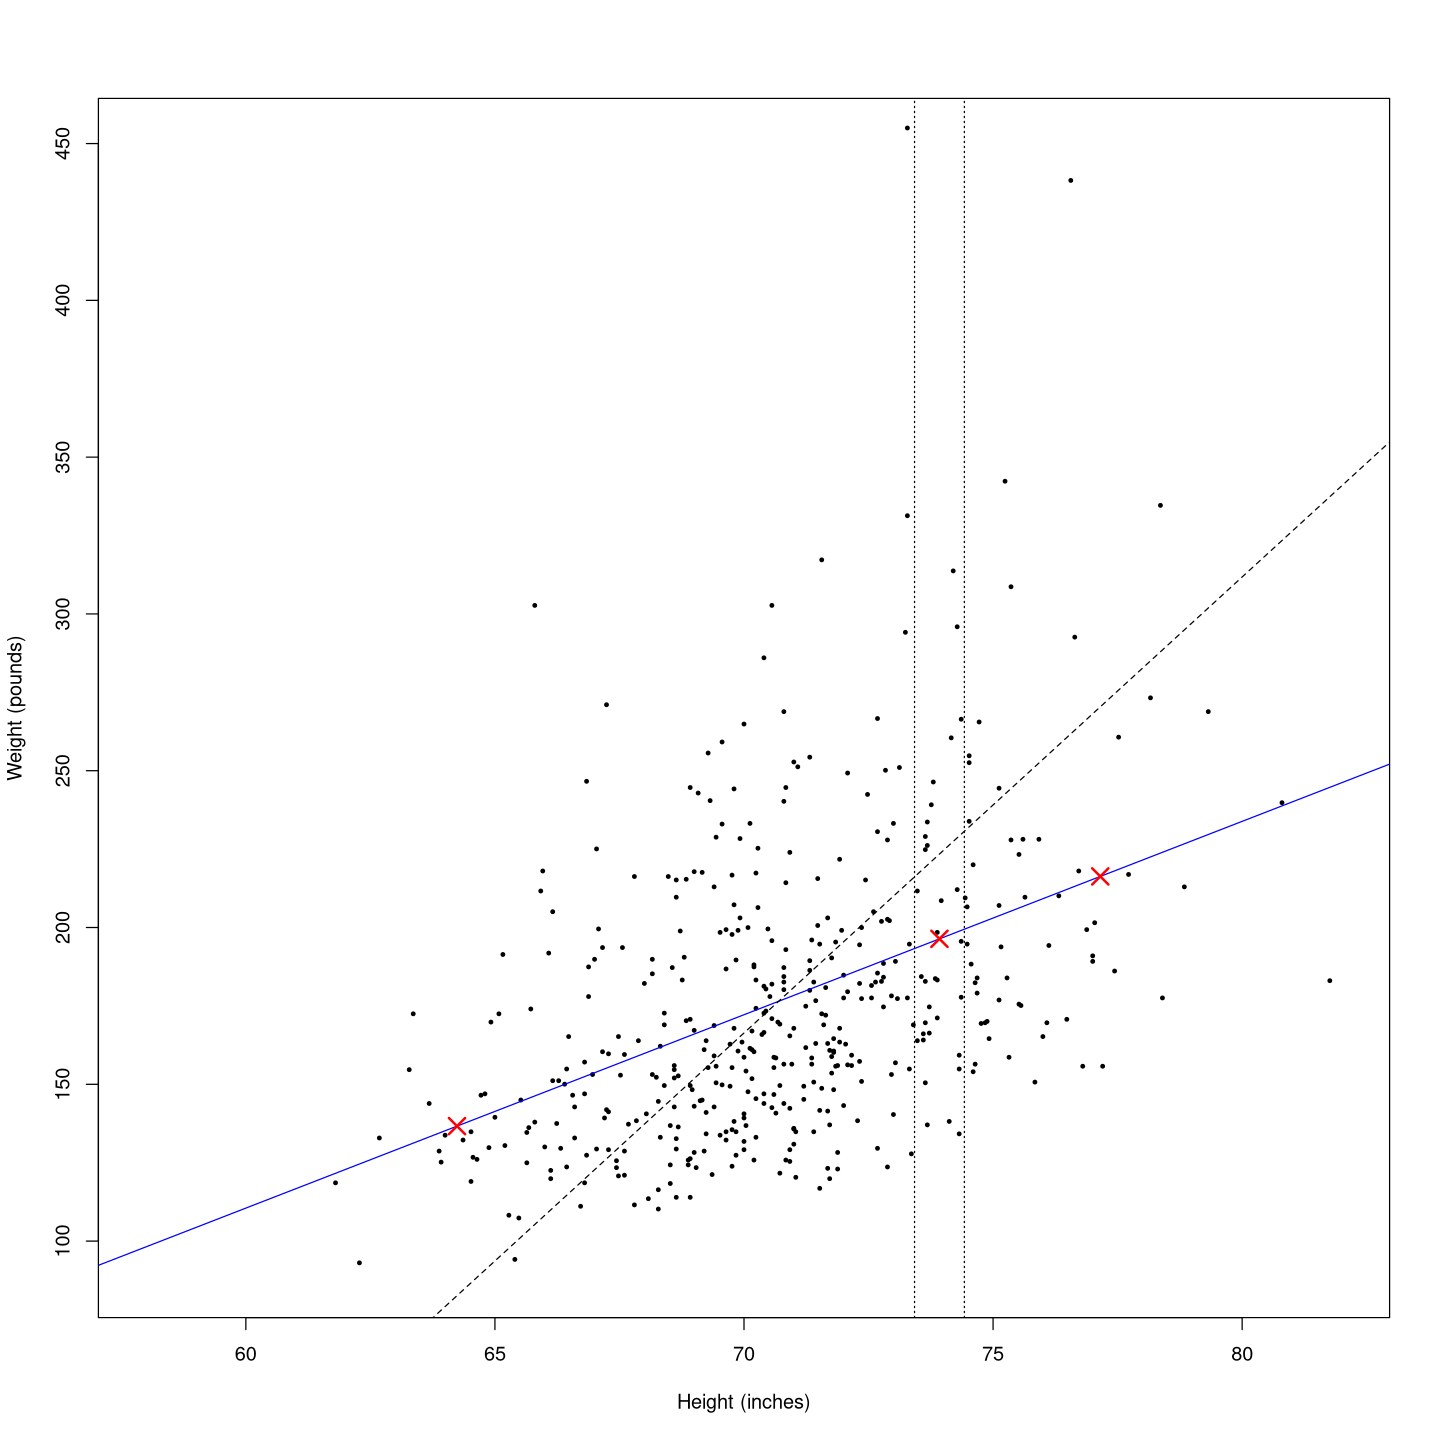

In [25]:
old.repr.plot.width=getOption("repr.plot.width")
old.repr.plot.height=getOption("repr.plot.height")
options(repr.plot.width=12, repr.plot.height=12)
plot(df$height, df$weight, pch=20, cex=.6, xlim=c(58, 82), ylim=c(90, 450), xlab="Height (inches)", ylab="Weight (pounds)")

# one SD strip
abline(v=(m.ht + sd.ht - .5), lty=3)
abline(v=(m.ht + sd.ht + .5), lty=3)

# The regression line
fit <- lm(weight ~ height, data=df)
abline(fit, col="blue")

# Plot some regression points
reg.x <- c(m.ht - 2 * sd.ht, m.ht + sd.ht, m.ht + 2 * sd.ht)
reg.y <- c(m.wt - 2 * cor.men * sd.wt, m.wt + cor.men * sd.wt, m.wt + 2 * cor.men * sd.wt)
points(reg.x, reg.y, pch=4, cex=1.8, lwd=2, col="red")

# The SD Line
sd.x <- c(m.ht + sd.ht, m.ht)
sd.y <- c(m.wt + sd.wt, m.wt)
sd.slope <- diff(sd.y) / diff(sd.x)
sd.intercept <- sd.y[1] - sd.slope * sd.x[1]
abline(a=sd.intercept, b=sd.slope, lty=2)

If a man is one SD above average height, what would his estimated weight be?

In [28]:
old.digits = getOption("digits")
options(digits=1)
cat("A man who is 1 SD above average height is:", m.ht + sd.ht, "inches.\n")
cat("For each SD increase in height, the weight increases by:", cor.men * sd.wt, "lb.\n")
cat("The estimated weight of the man 1 SD above average height is:", cor.men * sd.wt + m.wt, "lb.")
options(digits=old.digits)

A man who is 1 SD above average height is: 74 inches.
For each SD increase in height, the weight increases by: 20 lb.
The estimated weight of the man 1 SD above average height is: 196 lb.

The regression line for $y$ on $x$ estimates the average value for $y$ corresponding to each value of $x$.

Associated with each increase of one SD in $x$ there is an increase of only $r$ SDs in $y$, on the average.

In [29]:
rm(list=ls())

## Exercise Set A

### 1
In a certain class, midterm scores average out to $60$ with an SD of $15$, as do scores on the final. The correlation between midterm scores and final scores is about $0.50$. Estimate the average final score for the students whose midterm scores were  
(a) 75 &emsp; (b) 30 &emsp; (c) 60

Plot your regression estimates.

In [49]:
m.mid <- 60
m.final <- 60
sd.mid <- 15
sd.final <- 15
cor.mid.final <- 0.50
su.mid <- (75-m.mid)/sd.mid

cat("(a) 75:", m.final + sd.final * cor.mid.final, "\n")
cat("(b) 30:", m.final + ((30-m.mid)/sd.mid)*(sd.final * cor.mid.final), "\n")
cat("(c) 60:", m.final)
rm(list=ls())

(a) 75: 68 
(b) 30: 45 
(c) 60: 60

### 2
For the men age 18 and over in HANES5,  
&emsp;&emsp;average height $\approx$ 69 inches,&emsp;SD $\approx$ 3 inches  
&emsp;&emsp;average weight $\approx$ 190 pounds,&emsp;SD $\approx$ 42 pounds,&emsp;r $\approx$ 0.41  
Estimate the average weight of the men whose heights were  
&emsp;(a) 69 inches&emsp;&emsp;(b) 66 inches&emsp;&emsp;(c) 24 inches&emsp;&emsp;(d) 0 inches  
Comment on your answers to (c) and (d)

In [52]:
m.ht <- 69
sd.ht <- 3
m.wt <- 190
sd.wt <- 42
r <- 0.41
cat("(a) 69 inches", 190, "pounds.\n")
cat("(b) 66 inches", m.wt + ((66-m.ht)/sd.ht)*(sd.wt * r), "pounds\n")
cat("(c) 24 inches", m.wt + ((24-m.ht)/sd.ht)*(sd.wt * r), "pounds\n")
cat("(d) 0 inches",  m.wt + ((0-m.ht)/sd.ht)*(sd.wt * r), "pounds\n")
rm(list=ls())

(a) 69 inches 190 pounds.
(b) 66 inches 173 pounds
(c) 24 inches -68 pounds
(d) 0 inches -206 pounds


### 3
The men age 45&ndash;74 in HANES5 had an average height of 69 inches, equal to the overall average height (exercise 2). True or false, and explain: their average weight should be around 190 pounds, that being the overall average weight.

__FALSE__  
The men age 45&ndash;74 in the HANES5 represent a different population than the population described in exercise 2, which is all men age 18 and over.

### 4
For women age 25&ndash;34 in the U.S. in 2005, with full-time jobs, the relationship between education (years of schooling completed) and personal income can be summarized as follows:  
&emsp;&emsp;&emsp;&emsp;average education $\approx$ 14 years,&emsp;&emsp;SD $\approx$ 2.4 years  
&emsp;&emsp;&emsp;&emsp;average income $\approx \$32,000$,&emsp;&emsp;SD $\approx \$26,000$,&emsp;&emsp;r $\approx$ 0.34  
Estimate the average income of those women who have finished high school but have not gone on to college (so they have 12 years of education).

In [53]:
m.ed <- 14
sd.ed <- 2.4
m.inc <- 32000
sd.inc <- 26000
r <- 0.34
cat("For women who have 12 years of education, their estimated income is $", m.inc + ((12-m.ed)/sd.ed)*(sd.inc * r), "\n", sep="")

For women who have 12 years of education, their estimated income is $24633


### 5
Suppose $r=-1$. Can you explain why a one-SD increase in $x$ is matched by a one-SD decrease in $y$?  

The reason is with $r$ being negative, the correlation is inverted. As $x$ increases, $y$ will decrease.